[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](http://colab.research.google.com/github/AcademiXBase/deep-learning-from-scratch/blob/dev/my_notebooks/ch07.ipynb)

In [ ]:
# Colab で実行している場合、リポジトリをクローンする
#!git clone -b dev https://github.com/AcademiXBase/deep-learning-from-scratch.git
#%cd deep-learning-from-scratch/my_notebooks

In [ ]:
import os
import sys

# 実行環境の確認
if "google.colab" in sys.modules:
    print("✓ Running in Google Colab")
else:
    print("✗ Running locally (not Colab)")

print(f"Python version: {sys.version}")
print(f"Executable: {sys.executable}")
print(f"Working Directory: {os.getcwd()}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import ipywidgets as widgets

# ７章　畳み込みニューラルネットワーク

## 7.1 全体の構造

* 従来のニューラルネットワーク (全結合) は「Affine - ReLU」の繰り返しで構成  

* CNN (畳み込みニューラルネットワーク) では、「Convolution - ReLU - (Pooling)」というブロックに置き換わる  

* 出力層に近い部分では依然として「Affine - ReLU」が用いられ、最終出力は「Affine - Softmax」となる点は共通  


In [ ]:
# Mermaid Magic のインストール
!pip install -q mermaid-magic
%load_ext mermaid_magic

In [ ]:
%%mermaid
flowchart LR

A["MNIST image<br>28×28"] --> B["Flatten<br>784"]

subgraph L1["Layer 1"]
C["<br>Affine<br><br>"] --> D["<br>ReLU<br><br>"]
end

subgraph L2["Layer 2"]
E["<br>Affine<br><br>"] --> F["<br>ReLU<br><br>"]
end

subgraph L3["Layer 3"]
G["<br>Affine<br><br>"] --> H["<br>ReLU<br><br>"]
end

subgraph L4["Layer 4"]
I["<br>Affine<br><br>"] --> J["<br>Softmax<br><br>"]
end

subgraph L5["Layer 5"]
K["<br>Affine<br><br>"] --> L["<br>Softmax<br><br>"]
end

M["Output<br>10"]

B --> C
D --> E
F --> G
H --> I
J --> K
L --> M

classDef layer fill:#ffffff,stroke:#999,stroke-width:1px,color:#333;

class C,D,E,F,G,H,I,J,K,L layer

In [ ]:
%%mermaid
flowchart LR

A["MNIST image<br>28×28"]

subgraph L1["Layer 1"]
B["<br>Conv<br><br>"] --> C["<br>ReLU<br><br>"] --> D["<br>Pooling<br><br>"]
end

subgraph L2["Layer 2"]
E["<br>Conv<br><br>"] --> F["<br>ReLU<br><br>"] --> G["<br>Pooling<br><br>"]
end

subgraph L3["Layer 3"]
H["<br>Conv<br><br>"] --> I["<br>ReLU<br><br>"]
end

subgraph L4["Layer 4"]
J["<br>Affine<br><br>"] --> K["<br>ReLU<br><br>"]
end

subgraph L5["Layer 5"]
L["<br>Affine<br><br>"] --> M["<br>Softmax<br><br>"]
end

N["Output<br>10"]

A --> B
D --> E
G --> H
I --> J
K --> L
M --> N

classDef conv fill:#cccccc,stroke:#999,stroke-width:1px;
classDef pool fill:#cccccc,stroke:#999,stroke-width:1px;
classDef layer fill:#ffffff,stroke:#999,stroke-width:1px;

class B,E,H conv
class D,G pool
class C,F,I,J,K,L,M layer

## 7.2 畳み込み層

課題：全結合層 (Affine レイヤ) は入力データを 1 次元に平坦化 (フラット) する必要がある  

例：MNIST の画像 (1,28,28) は、784 個の 1 列のデータとして扱われる  

問題点：画像が持つ空間的な情報が失われる  

* 隣接するピクセルの関連性  

* RGB の各チャンネル間の関連性  

CNN の用語：  

畳み込み層の入出力データ：特徴マップ (feature map)  

⇒ 入力データのことを入力特徴マップという  

⇒ 出力データのことを出力特徴マップという  

### 畳み込み演算の処理

フィルター演算：入力データに対し、フィルター (カーネル) を一定間隔でスライドさせながら適用  

積和演算：フィルターの要素と入力の対応要素を乗算し、その総和を出力する  

バイアス：フィルター適用後のデータに対し、常に一つの値が加算される  

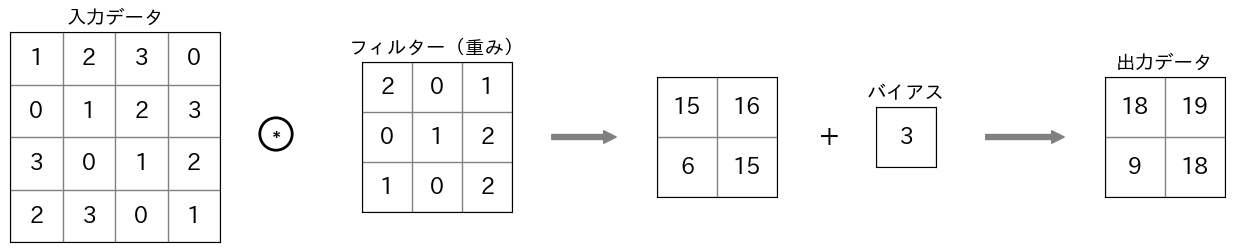

In [ ]:
# -------------------------
# サイズ設定
# -------------------------

H = 4
W = 4

FH = 3
FW = 3

OH = H - FH + 1
OW = W - FW + 1

# -------------------------
# データ
# -------------------------

#X = np.arange(H*W).reshape(H, W)
#K = np.random.randint(-3, 4, size=(FH, FW))
X = np.array([[1,  2,  3,  0],
              [0,  1,  2,  3],
              [3,  0,  1,  2],
              [2,  3,  0,  1]])

K = np.array([[2,  0,  1],
              [0,  1,  2],
              [1,  0,  2]])

b = 3

print(f"Output size: {OH}×{OW}")

In [ ]:
# -------------------------
# 畳み込み
# -------------------------

def conv2d(X, K, b):

    Y = np.zeros((OH, OW))

    for h in range(OH):
        for w in range(OW):
            Y[h,w] = np.sum(X[h:h+FH, w:w+FW] * K) + b

    return Y

Y = conv2d(X, K, b)


# -------------------------
# 描画
# -------------------------
def truncate_cmap(cmap, minval=0.2, maxval=0.8, n=256):

    new_cmap = colors.LinearSegmentedColormap.from_list(
        "trunc",
        cmap(np.linspace(minval, maxval, n))
    )

    return new_cmap

new_cmap = truncate_cmap(plt.get_cmap("bwr"), 0.2, 0.8)

def draw(k):

    Oh = k // OW
    Ow = k % OW

    fig, axes = plt.subplots(
        1,4,
        figsize=(14,4),
        width_ratios=[W, FW, 1, OW]
    )

    fig.subplots_adjust(wspace=0.4)

    # adjust color scale
    X_min = np.floor(X.min())
    X_max = np.ceil(X.max())
    Y_min = np.floor(Y.min())
    Y_max = np.ceil(Y.max())
    Kb_min  = np.floor(min(K.min(), b))
    Kb_max  = np.ceil(max(K.max(), b))

    # -----------------
    # X
    # -----------------

    ax = axes[0]

    ax.pcolor(
        X,
        cmap=new_cmap,
        vmin=X_min,
        vmax=X_max,
        edgecolor="gray"
    )

    rect = plt.Rectangle(
        (Ow, Oh),
        FW,
        FH,
        fill=False,
        edgecolor="yellow",
        linewidth=3,
        zorder=10,
        clip_on=False
    )

    ax.add_patch(rect)

    for h in range(H):
        for w in range(W):

            ax.text(
                w+0.5,
                h+0.5,
                f"{X[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("W")
    ax.set_ylabel("H")

    ax.set_title("X")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    # -----------------
    # K (kernel, filter)
    # -----------------

    ax = axes[1]

    ax.pcolor(
        K,
        cmap=new_cmap,
        vmin=Kb_min,
        vmax=Kb_max,
        edgecolor="gray"
    )

    for h in range(FH):
        for w in range(FW):

            ax.text(
                w+0.5,
                h+0.5,
                f"{K[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("FW")
    ax.set_ylabel("FH")

    ax.set_title("Filter")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    # -----------------
    # bias
    # -----------------

    ax = axes[2]

    ax.pcolor([[b]], cmap=new_cmap, vmin=Kb_min, vmax=Kb_max)

    ax.text(0.5,0.5,f"{b:.1f}",ha="center",va="center")

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("b")
    ax.set_aspect("equal")

    # -----------------
    # Y
    # -----------------

    ax = axes[3]

    ax.pcolor(
        Y,
        cmap=new_cmap,
        vmin=Y_min,
        vmax=Y_max,
        edgecolor="gray"
    )

    rect = plt.Rectangle(
        (Ow, Oh),
        1,
        1,
        fill=False,
        edgecolor="lawngreen",
        linewidth=3,
        zorder=10,
        clip_on=False
    )

    ax.add_patch(rect)

    for h in range(OH):
        for w in range(OW):

            ax.text(
                w+0.5,
                h+0.5,
                f"{Y[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("OW")
    ax.set_ylabel("OH")

    ax.set_title("Y")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    plt.show()


# -------------------------
# インタラクション
# -------------------------

_ = widgets.interact(
    draw,
    k=widgets.IntSlider(
        min=0,
        max=OH*OW-1,
        step=1,
        value=0,
        description="position"
    )
)

### 出力サイズを調整する方法

#### パディング (Padding)

* 入力データの周囲を固定値 (主に 0) で埋める処理  

* 出力サイズの調整 (データのサイズの縮小を防ぐ) が目的  

In [ ]:
# -------------------------
# サイズ設定
# -------------------------

H = 4
W = 4

FH = 3
FW = 3

P = 1   # padding

# -------------------------
# データ
# -------------------------

X = np.array([[1,2,3,0],
              [0,1,2,3],
              [3,0,1,2],
              [2,3,0,1]])

K = np.array([[2,0,1],
              [0,1,2],
              [1,0,2]])

b = 3

# -------------------------
# padding
# -------------------------

X_pad = np.pad(X, P)

H_pad, W_pad = X_pad.shape

OH = H + 2*P - FH + 1
OW = W + 2*P - FW + 1

print(f"Output size: {OH}×{OW}")

In [ ]:
# -------------------------
# 畳み込み
# -------------------------

def conv2d(X, K, b):

    Y = np.zeros((OH, OW))

    for h in range(OH):
        for w in range(OW):
            Y[h,w] = np.sum(X[h:h+FH, w:w+FW] * K) + b

    return Y

Y = conv2d(X_pad, K, b)


# -------------------------
# padding mask
# -------------------------

mask = np.zeros_like(X_pad, dtype=bool)

if P > 0:
    mask[:P,:] = True
    mask[-P:,:] = True
    mask[:,:P] = True
    mask[:,-P:] = True

X_plot = np.ma.array(X_pad, mask=mask)


# -------------------------
# 描画
# -------------------------
def truncate_cmap(cmap, minval=0.2, maxval=0.8, n=256):

    new_cmap = colors.LinearSegmentedColormap.from_list(
        "trunc",
        cmap(np.linspace(minval, maxval, n))
    )

    return new_cmap

new_cmap = truncate_cmap(plt.get_cmap("bwr"), 0.2, 0.8)

def draw(k):

    Oh = k // OW
    Ow = k % OW

    fig, axes = plt.subplots(
        1,4,
        figsize=(14,4),
        width_ratios=[W_pad, FW, 1, OW]
    )

    fig.subplots_adjust(wspace=0.4)

    # adjust color scale
    X_min = np.floor(X.min())
    X_max = np.ceil(X.max())
    Y_min = np.floor(Y.min())
    Y_max = np.ceil(Y.max())
    Kb_min  = np.floor(min(K.min(), b))
    Kb_max  = np.ceil(max(K.max(), b))

    # -----------------
    # X (padded)
    # -----------------

    ax = axes[0]

    ax.pcolor(
        X_plot,
        cmap=new_cmap,
        vmin=X_min,
        vmax=X_max,
        edgecolor="gray",
        #linestyle="--"
    )

    # sliding window
    rect = plt.Rectangle(
        (Ow, Oh),
        FW,
        FH,
        fill=False,
        edgecolor="yellow",
        linewidth=3,
        zorder=10,
        clip_on=False
    )

    ax.add_patch(rect)

    # padding枠
    if P > 0:
        rect_pad = plt.Rectangle(
            (P, P),
            W,
            H,
            fill=False,
            edgecolor="black",
            #linewidth=2,
            #linestyle="--"
        )

        ax.add_patch(rect_pad)

    for h in range(H_pad):
        for w in range(W_pad):

            ax.text(
                w+0.5,
                h+0.5,
                f"{X_pad[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("X (padded)")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    # -----------------
    # Filter
    # -----------------

    ax = axes[1]

    ax.pcolor(
        K,
        cmap=new_cmap,
        vmin=Kb_min,
        vmax=Kb_max,
        edgecolor="gray"
    )

    for h in range(FH):
        for w in range(FW):

            ax.text(
                w+0.5,
                h+0.5,
                f"{K[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("Filter")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    # -----------------
    # bias
    # -----------------

    ax = axes[2]

    ax.pcolor([[b]], cmap=new_cmap, vmin=Kb_min, vmax=Kb_max)

    ax.text(0.5,0.5,f"{b:.1f}",ha="center",va="center")

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("b")
    ax.set_aspect("equal")

    # -----------------
    # Y
    # -----------------

    ax = axes[3]

    ax.pcolor(
        Y,
        cmap=new_cmap,
        vmin=Y_min,
        vmax=Y_max,
        edgecolor="gray"
    )

    rect = plt.Rectangle(
        (Ow, Oh),
        1,
        1,
        fill=False,
        edgecolor="lawngreen",
        linewidth=3,
        zorder=10,
        clip_on=False
    )

    ax.add_patch(rect)

    for h in range(OH):
        for w in range(OW):

            ax.text(
                w+0.5,
                h+0.5,
                f"{Y[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("Y")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    plt.show()


# -------------------------
# インタラクション
# -------------------------

_ = widgets.interact(
    draw,
    k=widgets.IntSlider(
        min=0,
        max=OH*OW-1,
        step=1,
        value=0,
        description="position"
    )
)

#### ストライド (Stride)

* フィルターを適用する位置の間隔  

* ストライドを大きくすると、出力サイズは小さくなる  

In [ ]:
# -------------------------
# サイズ設定
# -------------------------

H = 4
W = 4

FH = 3
FW = 3

P = 1        # padding
S = 3        # stride

# -------------------------
# データ
# -------------------------

X = np.array([[1,2,3,0],
              [0,1,2,3],
              [3,0,1,2],
              [2,3,0,1]])

K = np.array([[2,0,1],
              [0,1,2],
              [1,0,2]])

b = 3

# -------------------------
# padding
# -------------------------

X_pad = np.pad(X, P)

H_pad, W_pad = X_pad.shape

# -------------------------
# stride
# -------------------------

if (H + 2*P - FH) % S != 0:
    raise ValueError(
        f"(H + 2P - FH) / S must be integer: {(H + 2*P - FH)}/{S}"
    )

if (W + 2*P - FW) % S != 0:
    raise ValueError(
        f"(W + 2P - FW) / S must be integer: {(W + 2*P - FW)}/{S}"
    )

# 出力サイズ
OH = (H + 2*P - FH) // S + 1
OW = (W + 2*P - FW) // S + 1

print(f"Output size: {OH}×{OW}")

In [ ]:
# -------------------------
# 畳み込み
# -------------------------

def conv2d(X, K, b, S):

    Y = np.zeros((OH, OW))

    for h in range(OH):
        for w in range(OW):

            h0 = h * S
            w0 = w * S

            Y[h,w] = np.sum(
                X[h0:h0+FH, w0:w0+FW] * K
            ) + b

    return Y

Y = conv2d(X_pad, K, b, S)


# -------------------------
# padding mask
# -------------------------

mask = np.zeros_like(X_pad, dtype=bool)

if P > 0:
    mask[:P,:] = True
    mask[-P:,:] = True
    mask[:,:P] = True
    mask[:,-P:] = True

X_plot = np.ma.array(X_pad, mask=mask)


# -------------------------
# 描画
# -------------------------
def truncate_cmap(cmap, minval=0.2, maxval=0.8, n=256):

    new_cmap = colors.LinearSegmentedColormap.from_list(
        "trunc",
        cmap(np.linspace(minval, maxval, n))
    )

    return new_cmap

new_cmap = truncate_cmap(plt.get_cmap("bwr"), 0.2, 0.8)

def draw(k):

    Oh = k // OW
    Ow = k % OW

    fig, axes = plt.subplots(
        1,4,
        figsize=(14,4),
        width_ratios=[W_pad, FW, 1, OW]
    )

    fig.subplots_adjust(wspace=0.4)

    # adjust color scale
    X_min = np.floor(X.min())
    X_max = np.ceil(X.max())
    Y_min = np.floor(Y.min())
    Y_max = np.ceil(Y.max())
    Kb_min  = np.floor(min(K.min(), b))
    Kb_max  = np.ceil(max(K.max(), b))

    # -----------------
    # X (padded)
    # -----------------

    ax = axes[0]

    ax.pcolor(
        X_plot,
        cmap=new_cmap,
        vmin=X_min,
        vmax=X_max,
        edgecolor="gray"
    )

    # sliding window
    rect = plt.Rectangle(
        (Ow*S, Oh*S),
        FW,
        FH,
        fill=False,
        edgecolor="yellow",
        linewidth=3,
        zorder=10,
        clip_on=False
    )

    ax.add_patch(rect)

    # padding枠
    if P > 0:
        rect_pad = plt.Rectangle(
            (P, P),
            W,
            H,
            fill=False,
            edgecolor="black"
        )

        ax.add_patch(rect_pad)

    for h in range(H_pad):
        for w in range(W_pad):

            ax.text(
                w+0.5,
                h+0.5,
                f"{X_pad[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("X (padded)")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    # -----------------
    # Filter
    # -----------------

    ax = axes[1]

    ax.pcolor(
        K,
        cmap=new_cmap,
        vmin=Kb_min,
        vmax=Kb_max,
        edgecolor="gray"
    )

    for h in range(FH):
        for w in range(FW):

            ax.text(
                w+0.5,
                h+0.5,
                f"{K[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("Filter")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    # -----------------
    # bias
    # -----------------

    ax = axes[2]

    ax.pcolor([[b]], cmap=new_cmap, vmin=Kb_min, vmax=Kb_max)

    ax.text(0.5,0.5,f"{b:.1f}",ha="center",va="center")

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("b")
    ax.set_aspect("equal")

    # -----------------
    # Y
    # -----------------

    ax = axes[3]

    ax.pcolor(
        Y,
        cmap=new_cmap,
        vmin=Y_min,
        vmax=Y_max,
        edgecolor="gray"
    )

    rect = plt.Rectangle(
        (Ow, Oh),
        1,
        1,
        fill=False,
        edgecolor="lawngreen",
        linewidth=3,
        zorder=10,
        clip_on=False
    )

    ax.add_patch(rect)

    for h in range(OH):
        for w in range(OW):

            ax.text(
                w+0.5,
                h+0.5,
                f"{Y[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("Y")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    plt.show()


# -------------------------
# インタラクション
# -------------------------

_ = widgets.interact(
    draw,
    k=widgets.IntSlider(
        min=0,
        max=OH*OW-1,
        step=1,
        value=0,
        description="position"
    )
)

まとめると...  

* パディングを大きくすると出力サイズは大きくなる  

* ストライドを大きくすると出力サイズは小さくなる  

### 出力サイズの求め方

入力サイズ：$(H,W)$  
フィルターサイズ：$(FH,FW)$  
出力サイズ：$(OH,OW)$  
ストライド：$S$  

$$ OH = \frac{H + 2P - FH}{S} + 1$$

$$ OW = \frac{W + 2P - FW}{S} + 1$$

例題 1：  

入力サイズ：(4,4)  
パディング：1  
ストライド：1  
フィルターサイズ：(3,3)  

$$OH = \frac{4+2 \cdot 1-3}{1} + 1 = 4$$
$$OW = \frac{4+2 \cdot 1-3}{1} + 1 = 4$$

例題 2：  

入力サイズ：(7,7)  
パディング：0  
ストライド：2  
フィルターサイズ：(3,3)  

$$OH = \frac{7+2 \cdot 0-3}{2} + 1 = 3$$
$$OW = \frac{4+2 \cdot 0-3}{2} + 1 = 3$$

例題 3：  

入力サイズ：(28,31)  
パディング：2  
ストライド：3  
フィルターサイズ：(5,5)  

$$OH = \frac{28+2 \cdot 2-5}{3} + 1 = 10$$
$$OW = \frac{31+2 \cdot 2-5}{3} + 1 = 11$$

出力サイズの値が整数にならない場合はエラーを出力するなどして対応する必要がある  

### 3 次元データの畳み込み演算

* 画像データは縦・横・チャンネル (RGB 等) の 3 次元形状  

* 規則：入力データのチャンネル数とフィルターのチャンネル数は同じ  

* 計算プロセス：チャンネルごとに畳み込みを行い、その結果を加算して 1 枚の出力を得る  

## プーリング層

* 定義：縦・横方向の空間を小さくする演算  

* Max プーリング：対象領域 (ウィンドウ) から「最大値」を取り出す手法  

* 設定：通常、ウィンドウサイズとストライドは同じ値 (例：2 × 2 ならストライドは 2)

In [ ]:
# -------------------------
# サイズ設定
# -------------------------

H = 4
W = 4

PH = 2     # pooling window height
PW = 2     # pooling window width

S = 2      # stride

# -------------------------
# データ
# -------------------------

X = np.array([[1,2,3,0],
              [0,1,2,3],
              [3,0,1,2],
              [2,3,0,1]])

# -------------------------
# 出力サイズ
# -------------------------

if (H - PH) % S != 0:
    raise ValueError("(H-PH)/S must be integer")

if (W - PW) % S != 0:
    raise ValueError("(W-PW)/S must be integer")

OH = (H - PH)//S + 1
OW = (W - PW)//S + 1

In [ ]:
# -------------------------
# Pooling
# -------------------------

def pooling2d(X, mode="max"):

    Y = np.zeros((OH,OW))

    for h in range(OH):
        for w in range(OW):

            h0 = h*S
            w0 = w*S

            patch = X[h0:h0+PH, w0:w0+PW]

            if mode == "max":
                Y[h,w] = np.max(patch)

            elif mode == "avg":
                Y[h,w] = np.mean(patch)

    return Y

# 初期出力
mode = "max"
Y = pooling2d(X, mode)


# -------------------------
# 描画
# -------------------------
def truncate_cmap(cmap, minval=0.2, maxval=0.8, n=256):

    new_cmap = colors.LinearSegmentedColormap.from_list(
        "trunc",
        cmap(np.linspace(minval, maxval, n))
    )

    return new_cmap

new_cmap = truncate_cmap(plt.get_cmap("bwr"), 0.2, 0.8)


def draw(k, mode):

    Y = pooling2d(X, mode)

    Oh = k // OW
    Ow = k % OW

    fig, axes = plt.subplots(
        1,2,
        figsize=(10,4),
        width_ratios=[W, OW]
    )

    fig.subplots_adjust(wspace=0.4)

    # adjust color scale
    X_min = np.floor(X.min())
    X_max = np.ceil(X.max())
    Y_min = np.floor(Y.min())
    Y_max = np.ceil(Y.max())

    # -----------------
    # X
    # -----------------

    ax = axes[0]

    ax.pcolor(
        X,
        cmap=new_cmap,
        vmin=X_min,
        vmax=X_max,
        edgecolor="gray"
    )

    rect = plt.Rectangle(
        (Ow*S, Oh*S),
        PW,
        PH,
        fill=False,
        edgecolor="yellow",
        linewidth=3,
        zorder=10,
        clip_on=False
    )

    ax.add_patch(rect)

    for h in range(H):
        for w in range(W):

            ax.text(
                w+0.5,
                h+0.5,
                f"{X[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("Input")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    # -----------------
    # Y
    # -----------------

    ax = axes[1]

    ax.pcolor(
        Y,
        cmap=new_cmap,
        vmin=Y_min,
        vmax=Y_max,
        edgecolor="gray"
    )

    rect = plt.Rectangle(
        (Ow, Oh),
        1,
        1,
        fill=False,
        edgecolor="lawngreen",
        linewidth=3,
        zorder=10,
        clip_on=False
    )

    ax.add_patch(rect)

    for h in range(OH):
        for w in range(OW):

            ax.text(
                w+0.5,
                h+0.5,
                f"{Y[h,w]:.1f}",
                ha="center",
                va="center"
            )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title("Pooling Output")

    ax.invert_yaxis()
    ax.set_aspect("equal")

    plt.show()


# -------------------------
# インタラクション
# -------------------------

_ = widgets.interact(
    draw,
    k=widgets.IntSlider(
        min=0,
        max=OH*OW-1,
        step=1,
        value=0,
        description="position"
    ),
    mode=widgets.Dropdown(
        options=["max","avg"],
        value="max",
        description="pooling"
    )
)

プーリング層の 3 つの特徴：  
1. 学習するパラメーターがない  

    最大値 (または平均) を取るだけの処理であり、重みやバイアスを持たない  

2. チャンネル数は変化しない  

    チャンネルごとに独立して計算が行われる  

3. 微小な位置変化に対してロバスト

    入力データが多少ズレても、プーリングの結果は変わりにくい  

## 参考資料

* [畳み込み演算の可視化【ゼロつく1のノート(実装)】][1]  

[1]: https://www.anarchive-beta.com/entry/2024/06/06/225935  